In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/clairett/pytorch-sentiment-classification/master/data/SST2/train.tsv"

df = pd.read_csv(
    url,
    sep='\t',
    header=None,
    names=['feedback','sentiment']
)

print(df.head())

df.to_csv(
    r"D:\Guvi\Projects\ride_flow_ai\data\raw\nlp_reviews.csv",
    index=False
)

print("Dataset Downloaded Successfully")

                                            feedback  sentiment
0  a stirring , funny and finally transporting re...          1
1  apparently reassembled from the cutting room f...          0
2  they presume their audience wo n't sit still f...          0
3  this is a visually stunning rumination on love...          1
4  jonathan parker 's bartleby should have been t...          1
Dataset Downloaded Successfully


In [3]:
df['sentiment'] = df['sentiment'].map({
    0:'negative',
    1:'positive'
})

print(df.head())

                                            feedback sentiment
0  a stirring , funny and finally transporting re...  positive
1  apparently reassembled from the cutting room f...  negative
2  they presume their audience wo n't sit still f...  negative
3  this is a visually stunning rumination on love...  positive
4  jonathan parker 's bartleby should have been t...  positive


In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/clairett/pytorch-sentiment-classification/master/data/SST2/train.tsv"

df = pd.read_csv(
    url,
    sep='\t',
    header=None,
    names=['feedback','sentiment']
)

df['sentiment'] = df['sentiment'].map({
    0:'negative',
    1:'positive'
})

print(df.head())

df.to_csv(
    r"D:\Guvi\Projects\ride_flow_ai\data\raw\nlp_reviews.csv",
    index=False
)

print("Dataset Downloaded Successfully")

                                            feedback sentiment
0  a stirring , funny and finally transporting re...  positive
1  apparently reassembled from the cutting room f...  negative
2  they presume their audience wo n't sit still f...  negative
3  this is a visually stunning rumination on love...  positive
4  jonathan parker 's bartleby should have been t...  positive
Dataset Downloaded Successfully


In [6]:
pip install nltk wordcloud

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.6 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 4.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np

import nltk
import re

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.svm import LinearSVC

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from wordcloud import WordCloud

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

In [4]:
nltk.download('stopwords')

nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [5]:
df = pd.read_csv(
    r"D:\Guvi\Projects\ride_flow_ai\data\raw\nlp_reviews.csv"
)

print(df.head())

print(df.shape)

                                            feedback sentiment
0  a stirring , funny and finally transporting re...  positive
1  apparently reassembled from the cutting room f...  negative
2  they presume their audience wo n't sit still f...  negative
3  this is a visually stunning rumination on love...  positive
4  jonathan parker 's bartleby should have been t...  positive
(6920, 2)


In [6]:
print(df.isnull().sum())

feedback     0
sentiment    0
dtype: int64


In [7]:
df = df.dropna()

In [28]:
lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#\w+", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    words = text.split()

    words = [

        lemmatizer.lemmatize(word)

        for word in words

        if word not in stop_words
        and len(word) > 2

    ]

    return " ".join(words)

In [19]:
df['cleaned_text'] = df['feedback'].apply(clean_text)

print(df[['feedback','cleaned_text']].head())

                                            feedback  \
0  a stirring , funny and finally transporting re...   
1  apparently reassembled from the cutting room f...   
2  they presume their audience wo n't sit still f...   
3  this is a visually stunning rumination on love...   
4  jonathan parker 's bartleby should have been t...   

                                        cleaned_text  
0  stir funny finally transport imagine beauty be...  
1  apparently reassemble cut room floor give dayt...  
2  presume audience wo n sit still sociology less...  
3  visually stun rumination love memory history w...  
4  jonathan parker bartleby end modern office ano...  


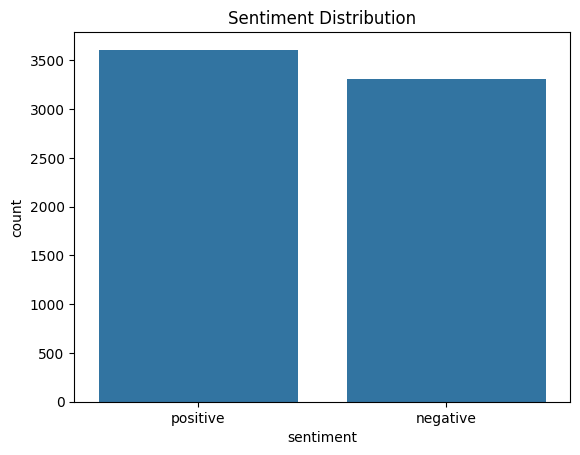

In [20]:
sns.countplot(
    x=df['sentiment']
)

plt.title("Sentiment Distribution")

plt.show()

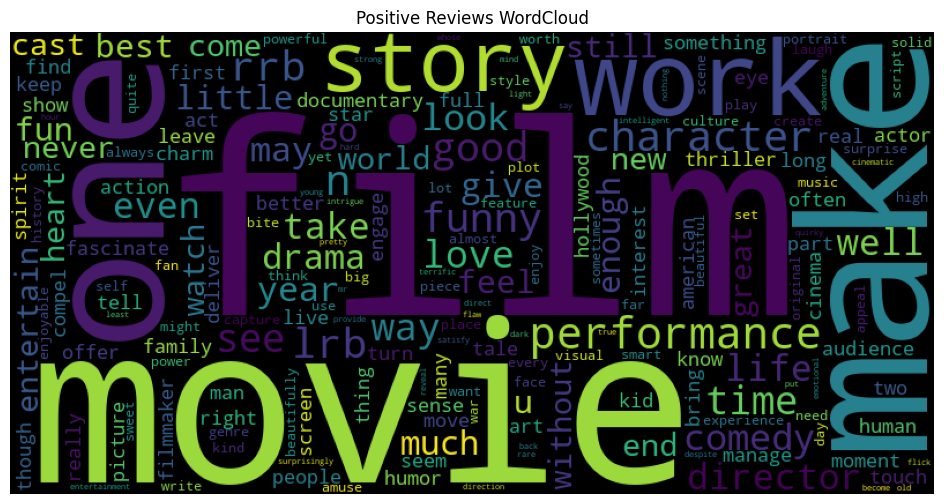

In [21]:
positive_text = " ".join(

    df[
        df['sentiment']=='positive'
    ]['cleaned_text']

)

wordcloud = WordCloud(
    width=800,
    height=400
).generate(positive_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Positive Reviews WordCloud")

plt.show()

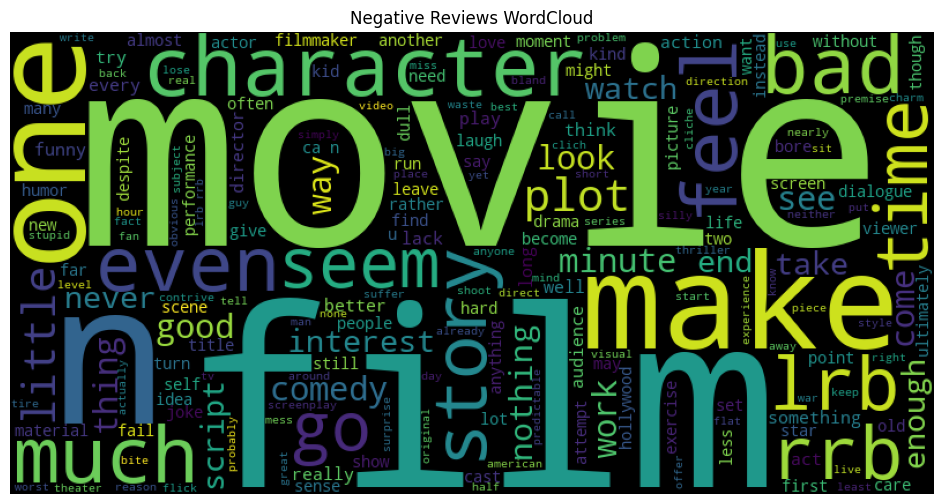

In [22]:
negative_text = " ".join(

    df[
        df['sentiment']=='negative'
    ]['cleaned_text']

)

wordcloud = WordCloud(
    width=800,
    height=400
).generate(negative_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Negative Reviews WordCloud")

plt.show()

In [23]:
X_train, X_test, y_train, y_test = train_test_split(

    df['cleaned_text'],

    df['sentiment'],

    test_size=0.2,

    random_state=42
)

In [29]:
nlp_model = Pipeline([

    (
        'tfidf',

        TfidfVectorizer(

            max_features=20000,

            ngram_range=(1,2),

            min_df=2,

            max_df=0.95,

            sublinear_tf=True
        )
    ),

    (
        'classifier',

        LogisticRegression(
            max_iter=2000
        )
    )

])

In [30]:
nlp_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [31]:
predictions = nlp_model.predict(X_test)

In [32]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy :", accuracy)

print(
    classification_report(
        y_test,
        predictions
    )
)

Accuracy : 0.7897398843930635
              precision    recall  f1-score   support

    negative       0.83      0.71      0.77       671
    positive       0.76      0.86      0.81       713

    accuracy                           0.79      1384
   macro avg       0.80      0.79      0.79      1384
weighted avg       0.79      0.79      0.79      1384



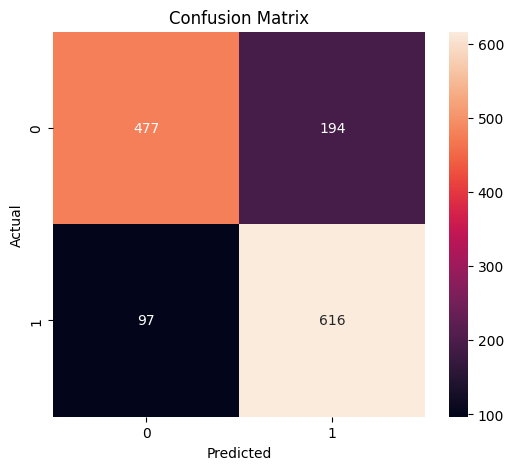

In [33]:
cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [27]:
sample_reviews = [

    "Driver was extremely rude",

    "Amazing ride experience",

    "Vehicle was dirty and uncomfortable",

    "Very affordable pricing"

]

cleaned_reviews = [

    clean_text(review)

    for review in sample_reviews
]

results = nlp_model.predict(
    cleaned_reviews
)

for review, result in zip(sample_reviews,results):

    print(review,"->",result)

Driver was extremely rude -> negative
Amazing ride experience -> positive
Vehicle was dirty and uncomfortable -> negative
Very affordable pricing -> positive


In [28]:
joblib.dump(

    nlp_model,

    r"D:\Guvi\Projects\ride_flow_ai\models\nlp_sentiment_model.pkl"

)

print("NLP Model Saved Successfully")

NLP Model Saved Successfully
